# Optimizing Position along Z-axis

### Position Dictionary
```
{'x': 0.0001729267, 'y': 2.8033e-05, 'z': 0.0001018735}
```

In [50]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import cv2
import torch
import torch.nn.functional as F

In [51]:
spad = camera_SPC3
spad._NFrames = 1 
spad._apply_camera_settings()

piezo = scanning_probe_logic

In [52]:
def measure_nv_brightness(position_dict, n_avg=5):
    piezo.set_target_position(position_dict)
    frames = []
    for _ in range(n_avg):
        frame = spad.start_single_acquisition()[0, 0, :, :]
        frames.append(frame)
    avg_frame = np.mean(frames, axis=0)
    total_brightness = np.sum(avg_frame)
    return total_brightness, frames

## Building the Sequence

In [53]:
arr_dim = 5
resolution_z = 50 # pixels
curr_pos = piezo.scanner_position
scan_range_z = 10.0e-6
z_l_bound, z_u_bound = piezo.scanner_constraints.axes['z'].position.bounds

initial_brightness_Z = measure_nv_brightness(curr_pos, n_avg=5)[0]

start_z = curr_pos['z'] - scan_range_z / 2
sequence_z = np.linspace(start_z, start_z + scan_range_z, int(resolution_z))

if sequence_z[0] < z_l_bound or sequence_z[-1] > z_u_bound:
    raise ValueError(f"Z scan range [{sequence_z[0]:.2e}, {sequence_z[-1]:.2e}] m exceeds scanner bounds [{z_l_bound:.2e}, {z_u_bound:.2e}] m")

w, h = spad.get_size()
array_size_microns = 2 * arr_dim - 1 
pxl_per_micron_x = w / array_size_microns  # 32 pixels / 9 microns = 3.56 pxl/micron
pxl_per_micron_y = h / array_size_microns

## Capture Images in Sequence

In [54]:
img_samples_Z = np.zeros((resolution_z, h, w), dtype=np.float32)
pos_dict = {k: float(v) for k, v in curr_pos.items()}

for idx, z_sample in enumerate(sequence_z):
    pos_dict['z'] = float(z_sample)

    position = piezo.set_target_position(pos_dict, move_blocking=True)
    
    frame = np.array(spad.start_single_acquisition()[0, 0, :, :])
    img_samples_Z[idx, :, :] = frame.astype(np.float32)
    print(f"Captured frame {idx}/{resolution_z}")

print(f"Final shape: {img_samples_Z.shape}")

Captured frame 0/50
Captured frame 1/50
Captured frame 2/50
Captured frame 3/50
Captured frame 4/50
Captured frame 5/50
Captured frame 6/50
Captured frame 7/50
Captured frame 8/50
Captured frame 9/50
Captured frame 10/50
Captured frame 11/50
Captured frame 12/50
Captured frame 13/50
Captured frame 14/50
Captured frame 15/50
Captured frame 16/50
Captured frame 17/50
Captured frame 18/50
Captured frame 19/50
Captured frame 20/50
Captured frame 21/50
Captured frame 22/50
Captured frame 23/50
Captured frame 24/50
Captured frame 25/50
Captured frame 26/50
Captured frame 27/50
Captured frame 28/50
Captured frame 29/50
Captured frame 30/50
Captured frame 31/50
Captured frame 32/50
Captured frame 33/50
Captured frame 34/50
Captured frame 35/50
Captured frame 36/50
Captured frame 37/50
Captured frame 38/50
Captured frame 39/50
Captured frame 40/50
Captured frame 41/50
Captured frame 42/50
Captured frame 43/50
Captured frame 44/50
Captured frame 45/50
Captured frame 46/50
Captured frame 47/50
Ca

## Calculating Focus Sharpness Metric

In [ ]:
img_samples_Z = np.nan_to_num(img_samples_Z, 0)

def sum_array_batched(imgs, pxl_per_micron_x, pxl_per_micron_y):
    """Apply kernel convolution to extract NV features at grid positions."""
    imgs = torch.from_numpy(imgs).float().unsqueeze(1)

    nv_size_x = int(pxl_per_micron_x)  # pixels per NV
    nv_size_y = int(pxl_per_micron_y)

    # Kernel stride
    spacing_x = int(2 * pxl_per_micron_x)  
    spacing_y = int(2 * pxl_per_micron_y)
    stride = (spacing_y, spacing_x)

    # Kernel = 1 micron NV box
    kernel = torch.ones((1, 1, nv_size_y, nv_size_x), dtype=imgs.dtype)

    out = F.conv2d(imgs, kernel, stride=stride, padding=0)
    brightness = out.squeeze(1).cpu().numpy()
    return brightness

def laplacian_variance_grid(imgs, roi_fraction=0.8):
    """
    Uses region of interest (ROI) to focus on center and larger kernel for better grid edge detection.
    
    Args:
        imgs: Array of images (N, H, W)
        roi_fraction: Fraction of image to use (0.8 = use center 80%)
    """
    sharpness = np.zeros(imgs.shape[0])
    h, w = imgs.shape[1], imgs.shape[2]
    
    roi_h = int(h * roi_fraction)
    roi_w = int(w * roi_fraction)
    y_start = (h - roi_h) // 2
    x_start = (w - roi_w) // 2
    
    for i in range(imgs.shape[0]):
        roi = imgs[i, y_start:y_start+roi_h, x_start:x_start+roi_w]
        
        img_uint8 = np.clip(roi, 0, 255).astype(np.uint8)
        
        laplacian = cv2.Laplacian(img_uint8, cv2.CV_64F, ksize=5)
        
        sharpness[i] = laplacian.var()
    
    return sharpness

def kernel_based_focus(imgs, pxl_per_micron_x, pxl_per_micron_y):
    """
    Focus metric based on NV grid kernel convolution.
    More accurate for grid patterns - focuses on actual NV positions.
    
    Args:
        imgs: Array of images (N, H, W)
        pxl_per_micron_x, pxl_per_micron_y: Kernel size parameters
    
    Returns:
        Sharpness metric for each image
    """
    nv_features = sum_array_batched(imgs, pxl_per_micron_x, pxl_per_micron_y)
    
    sharpness = np.var(nv_features, axis=(1, 2))
    
    return sharpness

# Calculate focus metrics using ALL methods for comparison
focus_kernel = kernel_based_focus(img_samples_Z, pxl_per_micron_x, pxl_per_micron_y)
focus_laplacian_grid = laplacian_variance_grid(img_samples_Z, roi_fraction=0.8)

print(f"Original: {img_samples_Z.shape}")
print(f"\n=== Focus Metric Comparison ===")
print(f"Kernel-based:  Range [{focus_kernel.min():.2f}, {focus_kernel.max():.2f}], Peak @ z={sequence_z[np.argmax(focus_kernel)]*1e6:.3f} µm")
print(f"Laplacian Grid: Range [{focus_laplacian_grid.min():.2f}, {focus_laplacian_grid.max():.2f}], Peak @ z={sequence_z[np.argmax(focus_laplacian_grid)]*1e6:.3f} µm")

# Select best method (you can change this)
focus_metric_Z = focus_kernel  # Using kernel-based as default

Original: (50, 32, 32)
Focus metric shape: (50,)
Focus metric range: [1463998.94, 2015796.70]


## Finding Position of Best Focus

### Compare Focus Methods

In [ ]:
# Plot all focus methods for comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: All methods overlaid
ax1 = axes[0]
ax1.plot(sequence_z * 1e6, focus_kernel / focus_kernel.max(), 'b-o', label='Kernel-based (normalized)', alpha=0.7, markersize=4)
ax1.plot(sequence_z * 1e6, focus_laplacian_grid / focus_laplacian_grid.max(), 'r-s', label='Laplacian Grid (normalized)', alpha=0.7, markersize=4)
ax1.set_xlabel("Z Position (µm)", fontsize=11)
ax1.set_ylabel("Normalized Focus Metric", fontsize=11)
ax1.set_title("Focus Method Comparison", fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Signal-to-noise comparison
ax2 = axes[1]
methods = ['Kernel\nBased', 'Laplacian\nGrid']
snr_values = []

for metric in [focus_kernel, focus_laplacian_grid]:
    peak = metric.max()
    baseline = metric.min()
    snr = (peak - baseline) / baseline if baseline > 0 else 0
    snr_values.append(snr)

ax2.bar(methods, snr_values, color=['blue', 'red'], alpha=0.7)
ax2.set_ylabel("Signal-to-Baseline Ratio", fontsize=11)
ax2.set_title("Focus Metric Sensitivity", fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n=== Method Performance ===")
for i, (name, metric) in enumerate([('Kernel-based', focus_kernel), ('Laplacian Grid', focus_laplacian_grid)]):
    peak_idx = np.argmax(metric)
    peak_val = metric[peak_idx]
    baseline = metric.min()
    snr = (peak_val - baseline) / baseline if baseline > 0 else 0
    print(f"{name:20s}: Peak={peak_val:8.2f}, SNR={snr:.3f}, Z_peak={sequence_z[peak_idx]*1e6:.3f} µm")

### Best Focus Position (Using Selected Method)

Best focus index: 32
Focus metric value: 2015796.70
Captured frame 1/5
Captured frame 2/5
Captured frame 3/5
Captured frame 4/5
Captured frame 5/5


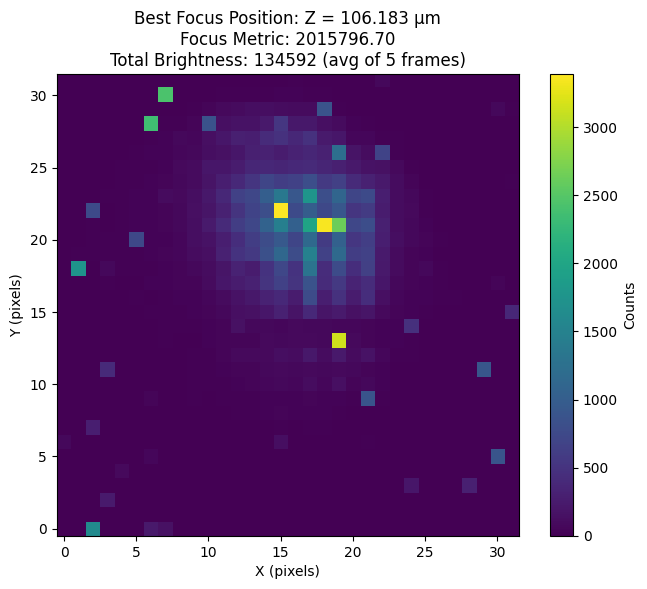

Position index: 32
Physical position: z=106.183 µm
Focus metric from scan: 2015796.70
Total frame brightness: 134592


In [56]:
idx_max = np.argmax(focus_metric_Z)
print(f"Best focus index: {idx_max}")
print(f"Focus metric value: {focus_metric_Z[idx_max]:.2f}")
pos_z_max = sequence_z[idx_max]

pos_dict['z'] = float(pos_z_max)
position = piezo.set_target_position(pos_dict, move_blocking=True)

frames = []
for i in range(5):
    single_frame = np.array(spad.start_single_acquisition()[0, 0, :, :])
    frames.append(single_frame)
    print(f"Captured frame {i+1}/5")

frame = np.mean(frames, axis=0)
frame = np.flipud(frame)
total_brightness = np.sum(frame)

plt.figure(figsize=(8, 6))
plt.imshow(frames[-1], origin='lower')
plt.colorbar(label='Counts')
plt.title(f'Best Focus Position: Z = {pos_z_max*1e6:.3f} µm\nFocus Metric: {focus_metric_Z[idx_max]:.2f}\nTotal Brightness: {total_brightness:.0f} (avg of 5 frames)')
plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')
plt.show()

print(f"Position index: {idx_max}")
print(f"Physical position: z={pos_z_max*1e6:.3f} µm")
print(f"Focus metric from scan: {focus_metric_Z[idx_max]:.2f}")
print(f"Total frame brightness: {total_brightness:.0f}")

## Fitting to a Gaussian Distribution

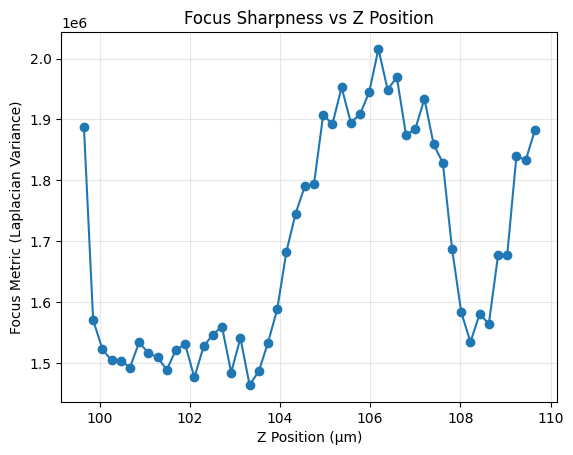

In [57]:
plt.plot(sequence_z * 1e6, focus_metric_Z, marker='o', linestyle='-')
plt.xlabel("Z Position (µm)")
plt.ylabel("Focus Metric (Laplacian Variance)")
plt.title("Focus Sharpness vs Z Position")
plt.grid(True, alpha=0.3)
plt.show()

In [58]:
def gaussian(x, amp, mu, sigma, offset):
    return amp * np.exp(-(x - mu)**2 / (2 * sigma**2)) + offset

p0 = [
    focus_metric_Z.max() - focus_metric_Z.min(), # amplitude
    sequence_z[np.argmax(focus_metric_Z)], # center
    np.std(sequence_z), # width
    focus_metric_Z.min() # offset
]

bounds_z = (
    [0.0, sequence_z[0], 1e-12, -np.inf], 
    [np.inf, sequence_z[-1], np.inf, np.inf]
)

popt, _ = curve_fit(gaussian, sequence_z, focus_metric_Z, p0=p0, bounds=bounds_z)

# sse = float(np.sum(resid**2))
# sst = float(np.sum((nv_brightness - np.mean(nv_brightness))**2))
# r2 = 1.0 - (sse / sst) if sst > 0 else float("nan")
# rmse = float(np.sqrt(np.mean(resid**2)))
A_fit, z_fit, sigma, C_fit = popt
pos_dict['z'] = float(z_fit)
position = piezo.set_target_position(pos_dict, move_blocking=True)

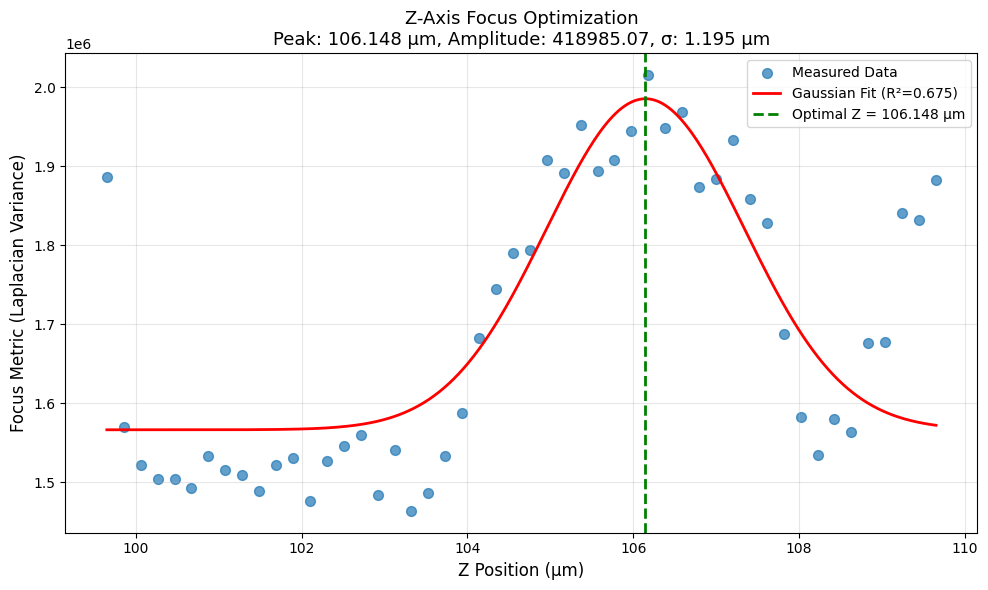

Optimal Z position: 106.148 µm (1.061483e-04 m)
Gaussian width (σ): 1.195 µm
Focus amplitude: 418985.07, Background: 1566686.02
R²: 0.6749, RMSE: 101401.0170


In [59]:
x_axis = np.linspace(min(sequence_z), max(sequence_z), 500)
y_axis = gaussian(x_axis, *popt)

resid = focus_metric_Z - gaussian(sequence_z, *popt)
sse = float(np.sum(resid**2))
sst = float(np.sum((focus_metric_Z - np.mean(focus_metric_Z))**2))
r2 = 1.0 - (sse / sst) if sst > 0 else float("nan")
rmse = float(np.sqrt(np.mean(resid**2)))

plt.figure(figsize=(10, 6))
plt.scatter(sequence_z * 1e6, focus_metric_Z, label="Measured Data", s=50, alpha=0.7)
plt.plot(x_axis * 1e6, y_axis, 'r-', label=f"Gaussian Fit (R²={r2:.3f})", linewidth=2)
plt.axvline(z_fit * 1e6, color='green', linestyle='--', linewidth=2, label=f'Optimal Z = {z_fit*1e6:.3f} µm')
plt.xlabel("Z Position (µm)", fontsize=12)
plt.ylabel("Focus Metric (Laplacian Variance)", fontsize=12)
plt.title(f"Z-Axis Focus Optimization\nPeak: {z_fit*1e6:.3f} µm, Amplitude: {A_fit:.2f}, σ: {sigma*1e6:.3f} µm", fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal Z position: {z_fit*1e6:.3f} µm ({z_fit:.6e} m)")
print(f"Gaussian width (σ): {sigma*1e6:.3f} µm")
print(f"Focus amplitude: {A_fit:.2f}, Background: {C_fit:.2f}")
print(f"R²: {r2:.4f}, RMSE: {rmse:.4f}")

Captured frame 1/5
Captured frame 2/5
Captured frame 3/5
Captured frame 4/5
Captured frame 5/5


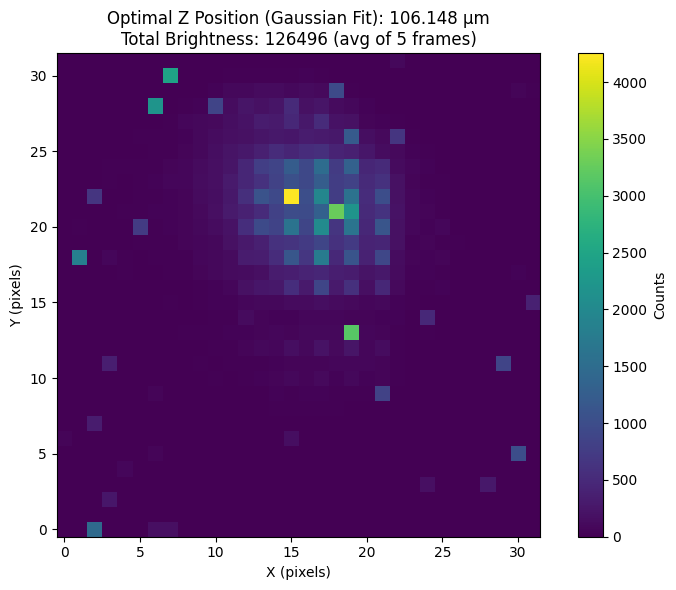


Image captured at optimal Z = 106.148 µm
Total brightness: 126496 counts


In [60]:
frames = []
for i in range(5):
    single_frame = np.array(spad.start_single_acquisition()[0, 0, :, :])
    frames.append(single_frame)
    print(f"Captured frame {i+1}/5")

frame_avg = np.mean(frames, axis=0)
frame_avg = np.flipud(frame_avg)
total_brightness = np.sum(frame_avg)

plt.figure(figsize=(8, 6))
plt.imshow(frames[-1], origin='lower')
plt.colorbar(label='Counts')
plt.title(f'Optimal Z Position (Gaussian Fit): {z_fit*1e6:.3f} µm\nTotal Brightness: {total_brightness:.0f} (avg of 5 frames)')
plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')
plt.tight_layout()
plt.show()

print(f"\nImage captured at optimal Z = {z_fit*1e6:.3f} µm")
print(f"Total brightness: {total_brightness:.0f} counts")

In [ ]:
# Calculate focus metric for optimized position
final_focus_metric = kernel_based_focus(frame_avg.reshape(1, frame_avg.shape[0], frame_avg.shape[1]), pxl_per_micron_x, pxl_per_micron_y)[0]

# Get initial focus metric from the scan data
initial_idx = np.argmin(np.abs(sequence_z - curr_pos['z']))
initial_focus_metric = focus_metric_Z[initial_idx]

print(f"\n=== Optimization Results ===")
print(f"Starting focus metric: {initial_focus_metric:.2f}")
print(f"Final focus metric: {final_focus_metric:.2f}")
print(f"Focus improvement: {((final_focus_metric - initial_focus_metric) / initial_focus_metric * 100):.1f}%")
print(f"\nStarting brightness: {initial_brightness_Z:.0f} counts")
print(f"Final brightness: {total_brightness:.0f} counts")
print(f"Brightness change: {((total_brightness - initial_brightness_Z) / initial_brightness_Z * 100):.1f}%")

if final_focus_metric < initial_focus_metric * 0.95:  # Allow 5% tolerance
    print("\nOptimization may have failed (focus decreased). Reverting to original position.")
    piezo.set_target_position(curr_pos)
else:
    print(f"\nOptimization successful! Focus improved.")


=== Optimization Results ===
Starting focus metric: 1790182.39
Final focus metric: 25791.55
Focus improvement: -98.6%

Starting brightness: 113178 counts
Final brightness: 126496 counts
Brightness change: 11.8%

Optimization may have failed (focus decreased). Reverting to original position.
